
<font color="#CA3532"><h1 align="left">Sistema multimodal para la detección e identificación de especies de hongos mediante visión por computador y modelos de lenguaje</h1></font>
<font color="#6E6E6E"><h2 align="left">Creación del modelo</h2></font>

#### David Alejandro Pedroza De Jesús

#   Librerias usadas

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from google.colab import drive
import shutil
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import os

# Descarga de datos.

Este paso se hace para tener los datos subidos en la nube.



In [3]:
drive.mount('/content/drive/')

Mounted at /content/drive/


In [4]:
shutil.copy(
    "/content/drive/MyDrive/kaggle.zip",

    "/content/")

'/content/kaggle.zip'

In [5]:
!unzip kaggle.zip

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39104medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39105medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39106medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39107medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39108medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39109medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39110medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39111medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39112medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39113medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39114medium.jpg  
  inflating: kaggle/working/merged_dataset/

#   Carga de los CSVs

Cargamos y modificamos como en el notebook anterior; el primer paso será cargarlos.

In [6]:
rutas_val = pd.read_csv("kaggle/working/val.csv")
rutas_train = pd.read_csv("kaggle/working/train.csv")
rutas_test = pd.read_csv("kaggle/working/test.csv")
info_especies = pd.read_csv("InfoEspecies.csv")
info_especies = info_especies.drop(info_especies.columns[0], axis= "columns")

Obtenemos sus versiones reducidas usando las funciones creadas en el notebook anterio.

In [7]:
def muestras_data_set(df,n, seed, use_seed = False):
    especies = pd.unique(df.label)
    df_final = pd.DataFrame(columns=df.columns)
    for especie in especies:
        df_fil = df[df.label == especie]
        if use_seed:
            df_fil = df_fil.sample(n=n, random_state=seed)
        else:
            df_fil = df_fil.sample(n=n)
        df_final = pd.concat([df_final, df_fil], ignore_index=True)
    return df_final

Y ahora aplicamos un inner join para filtrar las especies que solo se encuentran en Valencia, además esto añadirá una columna para saber cuales son comestibles y cuales no.

In [9]:
train = pd.merge(info_especies, rutas_train, on='label', how='inner')
test = pd.merge(info_especies, rutas_test, on='label', how='inner')
val = pd.merge(info_especies, rutas_val, on='label', how='inner')

Arregamos las rutas para que sean correctas.

In [10]:
def ArreglarLasRutas(df):
    rutas_nuevas = []
    for path in df.image_path:
        path = path.lstrip("/")
        rutas_nuevas.append(path)
    df.image_path = rutas_nuevas

dfs = [train, val, test]
for df in dfs:
    ArreglarLasRutas(df)


Ahora creamos el directorio final de datos.

In [11]:
def Modificar_direc(df_rutas, subset):
    os.makedirs(f"Data/{subset}", exist_ok=True)

    ArreglarLasRutas(df_rutas)

    for path, label in zip(df_rutas.image_path, df_rutas.label):
        destino = f"Data/{subset}/{label}/"
        os.makedirs(destino, exist_ok=True)
        print(f"Copiando {path} --> {destino}")
        shutil.copy(path, destino)
        print(f"Terminado {label}")

In [12]:
Modificar_direc(train, "train")
Modificar_direc(val, "val")
Modificar_direc(test, "test")

Se han truncado las últimas 5000 líneas del flujo de salida.
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/23848medium.jpeg --> Data/test/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/22520medium.jpeg --> Data/test/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/19797medium.jpeg --> Data/test/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/21250medium.jpeg --> Data/test/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/20305medium.jpeg --> Data/test/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/23631medium.jpg --> Data/test/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/21238medium.jpg --> Data/test/Fomit

Ahora cargamos las imagenes usando lo obtenido en el chunk anterior.

In [13]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 128

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "Data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    "Data/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

BATCH_SIZE = 128
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "Data/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_dataset = test_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

train_dataset = train_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

val_dataset = val_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)


Found 30068 files belonging to 54 classes.
Found 6443 files belonging to 54 classes.
Found 6442 files belonging to 54 classes.


#   MobileNetV2

Ahora haremos la prueba para movil net, seguiremos los siguientes pasos:
-   Cargamos el modelo usando los pesos del conjunto de datos imagenet

In [14]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(64, 64, 3))


/tmp/ipykernel_5359/2851871073.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(64, 64, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


-   Añadiremos más capas al final para que podamos definir el numero de clases y alguna capa de procesado más.

In [15]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(54, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)


-   Compilamos el modelo usando adam y categorical crossentropy.

In [16]:
for layer in base_model.layers:
    layer.trainable = False

optimizer = tf.keras.optimizers.Adam()
model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


-   Ahora entrenamos.

In [17]:
hist = model.fit(train_dataset, validation_data = val_dataset, epochs=30)

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 140s 512ms/step - accuracy: 0.3425 - loss: 2.6862 - val_accuracy: 0.4139 - val_loss: 2.3002
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 97s 415ms/step - accuracy: 0.4602 - loss: 2.0186 - val_accuracy: 0.4330 - val_loss: 2.1960
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 76s 324ms/step - accuracy: 0.5067 - loss: 1.8007 - val_accuracy: 0.4413 - val_loss: 2.1757
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 63s 266ms/step - accuracy: 0.5396 - loss: 1.6575 - val_accuracy: 0.4448 - val_loss: 2.1844
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 63s 268ms/step - accuracy: 0.5651 - loss: 1.5533 - val_accuracy: 0.4427 - val_loss: 2.1972
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 74s 313ms/step - accuracy: 0.5899 - loss: 1.4674 - val_accuracy: 0.4465 - val_loss: 2.2101
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 71s 268ms/step - accuracy: 0.6072 - loss: 1.4001 - val_accuracy: 0.4430 - val_loss: 2.2423
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 92s 311ms/step - accuracy: 0.6211 - loss: 

Mostramos graficos del modelo.

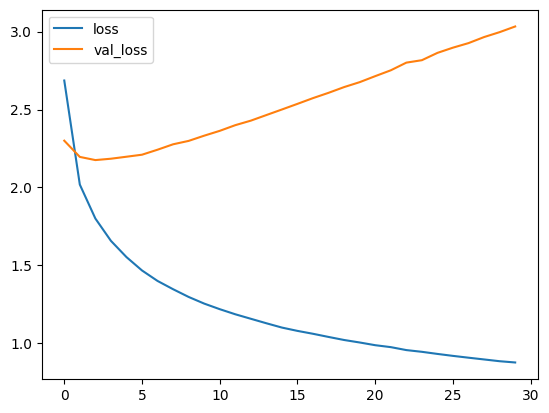

In [18]:
plt.plot(hist.history['loss'],label="loss")
plt.plot(hist.history['val_loss'],label="val_loss")
plt.legend()
plt.show()

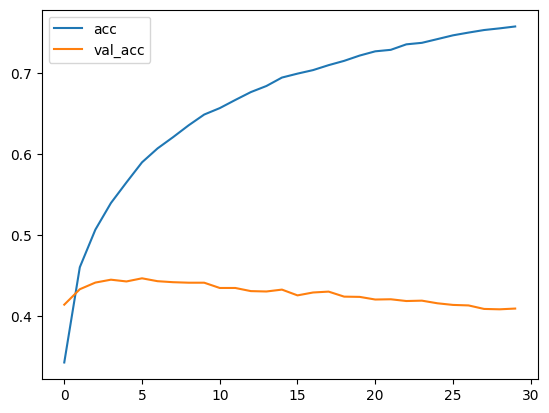

In [19]:
plt.plot(hist.history['accuracy'],label="acc")
plt.plot(hist.history['val_accuracy'],label="val_acc")
plt.legend()
plt.show()

In [20]:
#model = tf.keras.models.load_model("/content/drive/MyDrive/MobileNetV2Tune.keras")

In [21]:
y_pred = model.predict(test_dataset)

51/51 ━━━━━━━━━━━━━━━━━━━━ 31s 497ms/step


In [22]:
model.evaluate(test_dataset)

51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 277ms/step - accuracy: 0.4022 - loss: 3.0882


[3.088222026824951, 0.4022042751312256]

In [23]:
from sklearn.metrics import confusion_matrix

y_true = np.concatenate([y for x, y in test_dataset], axis=0)
y_true_classes = np.argmax(y_true, axis=1)

cm = confusion_matrix(y_true_classes, np.argmax(y_pred, axis=1),
                      normalize= "true")


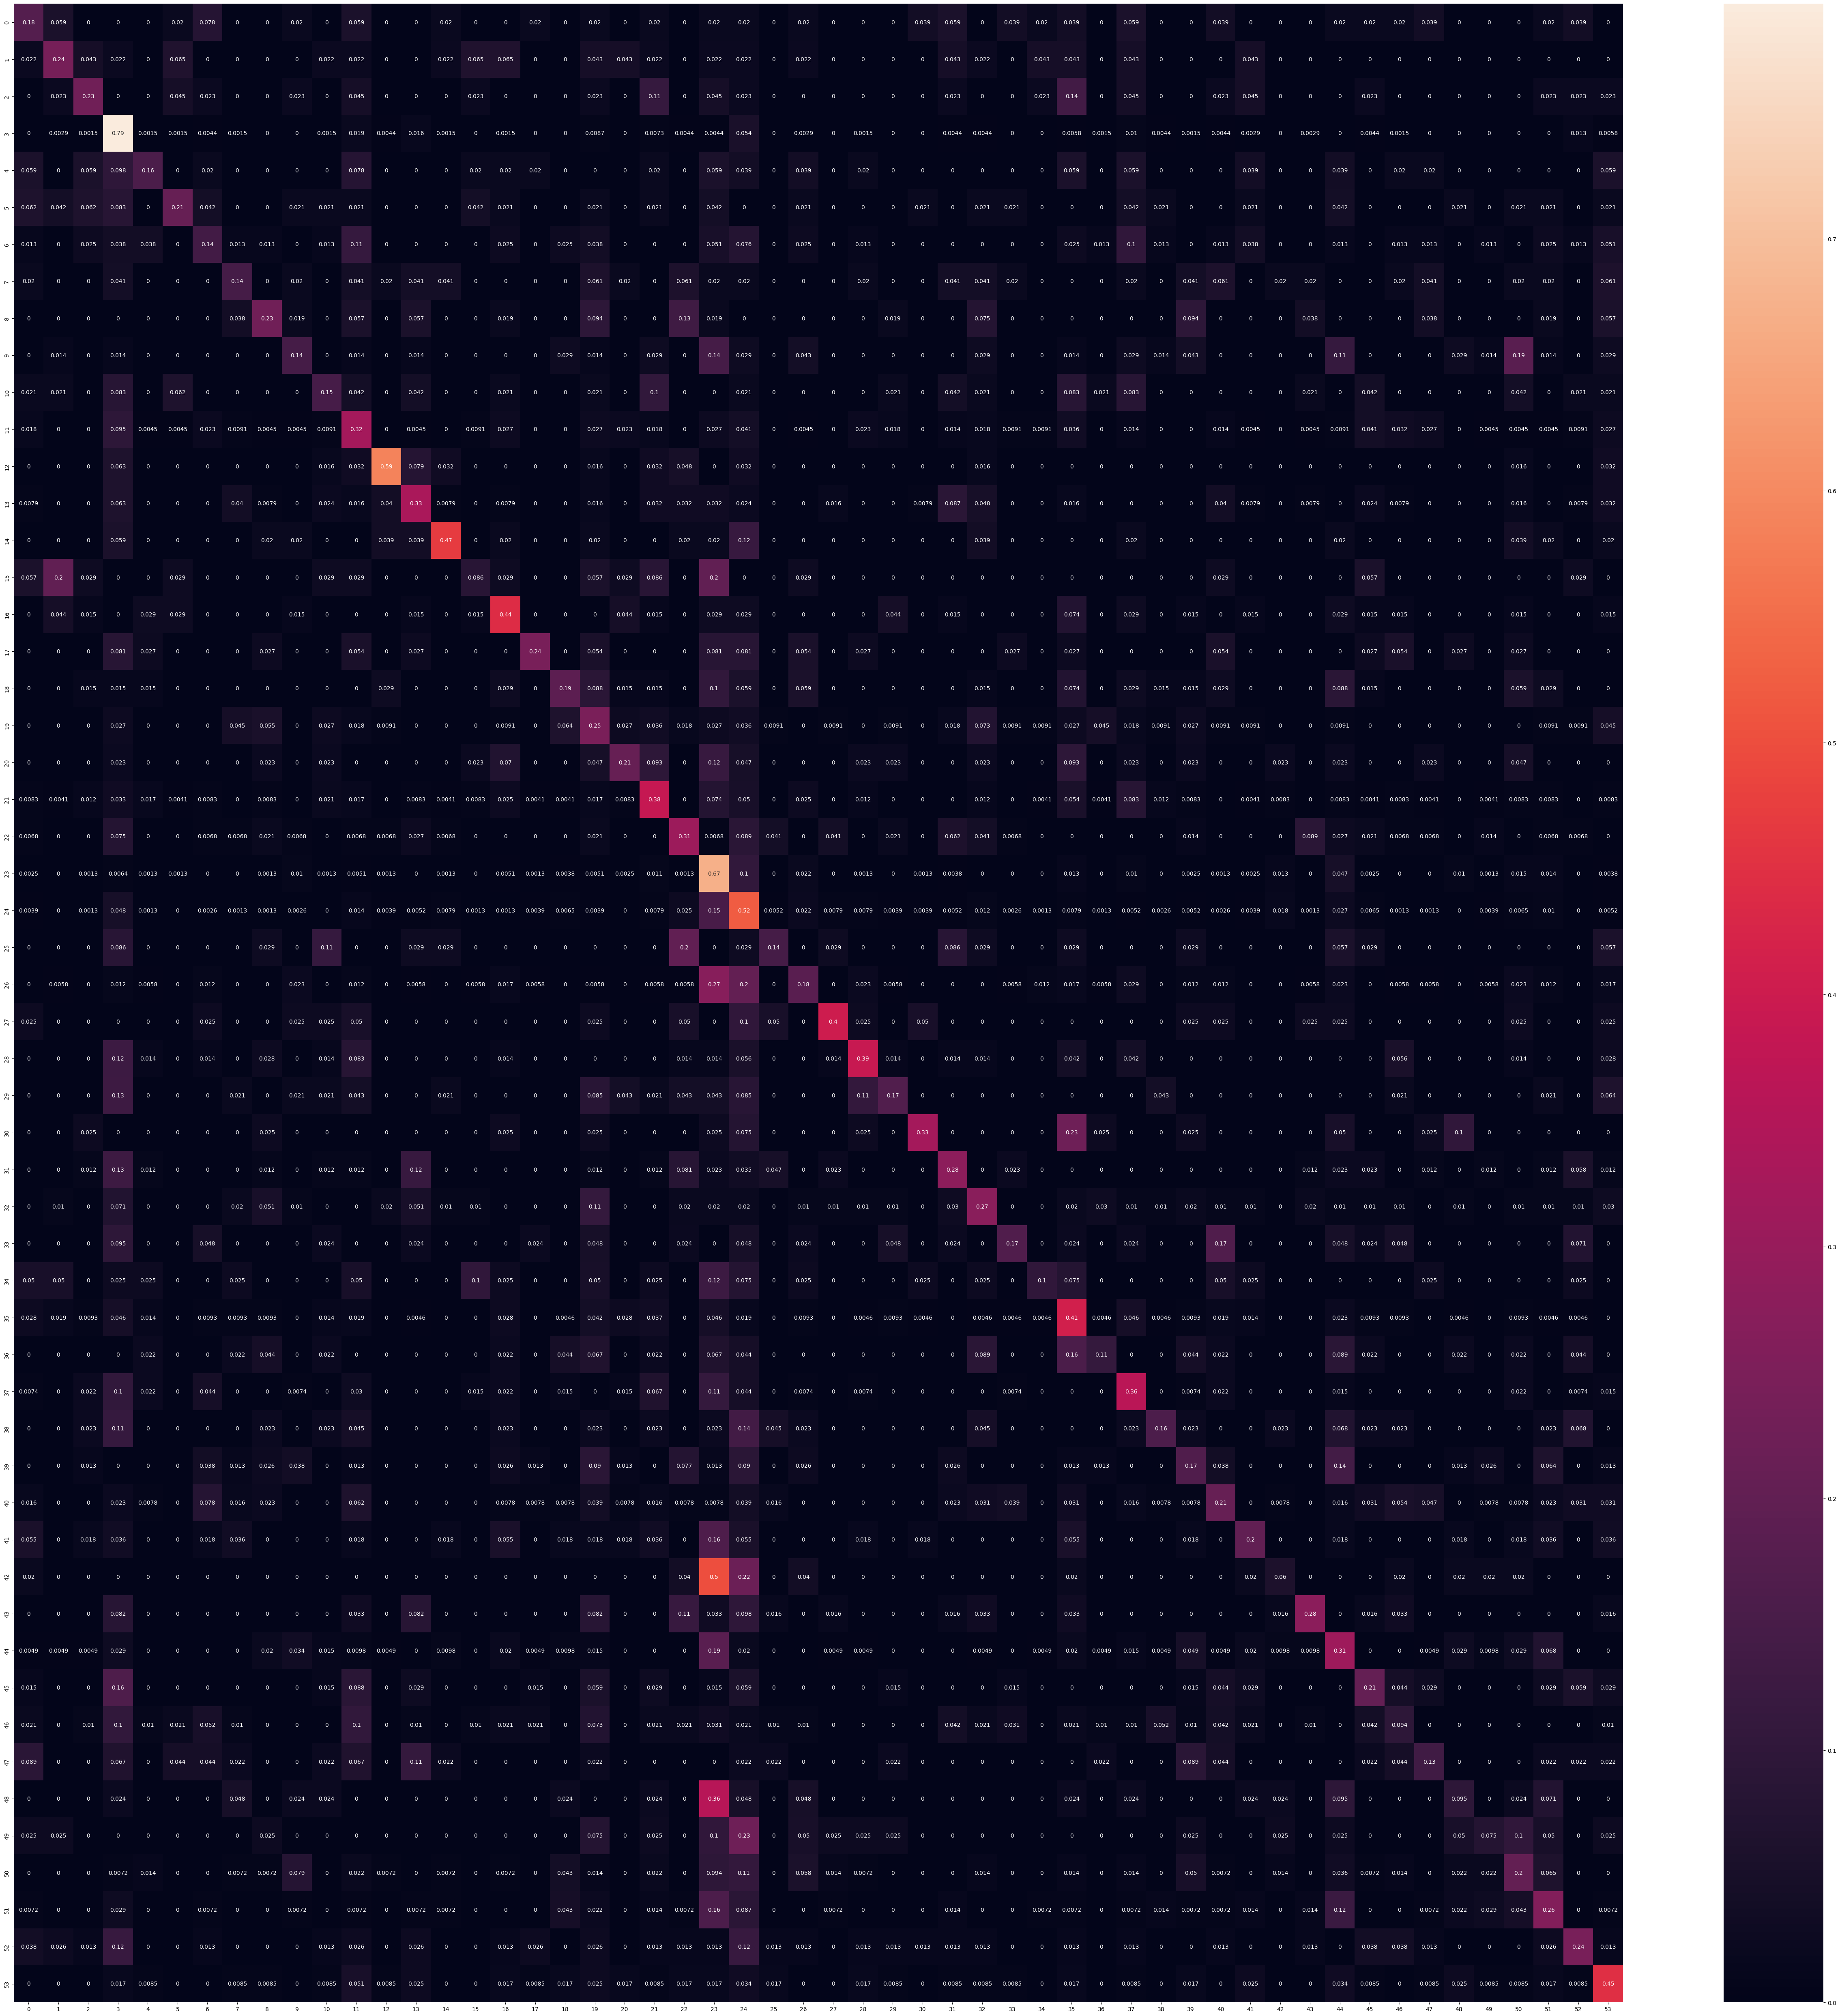

In [24]:
import seaborn as sns
plt.figure(figsize=(64,64))
sns.heatmap(cm, annot= True)
plt.show()


In [25]:
model.save("MobileNetV2Tune.keras")


shutil.copy(
    "MobileNetV2Tune.keras",
    "/content/drive/MyDrive/")


df_hist = pd.DataFrame(hist.history)
df_hist.to_csv("movile_results.csv", index=False)
shutil.copy(
    "movile_results.csv",
    "/content/drive/MyDrive/")



'/content/drive/MyDrive/movile_results.csv'